## ADHD Quantitative EDA
Data from WiDS Datathon 2025. Predicting gender and ADHD.
- 1213 datapoints
- labels: ADHD (0, 1-ADHD) and gender (0, 1-female)
- features: functional MRI connectome matrices (19900 cols) and patient information (socio-demographic, emotions, and parenting)
- categorical
- quantitative


Questions:
- categorical variables - Cramer's v statistic
- ordinal variables - Spearman's rank, Goodman and Kruskal's gamma, Kendal's tau (?)

Findings:


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import sklearn
import umap

## Labels

In [2]:
labels = pd.read_excel("../data/TRAIN/TRAINING_SOLUTIONS.xlsx")
conditions = [
    (labels["ADHD_Outcome"] == 1) & (labels["Sex_F"] == 1),
    (labels["ADHD_Outcome"] == 1) & (labels["Sex_F"] == 0),
    (labels["ADHD_Outcome"] == 0) & (labels["Sex_F"] == 1),
    (labels["ADHD_Outcome"] == 0) & (labels["Sex_F"] == 0),
]
values = ["ADHD_F", "ADHD_M", "norm_F", "norm_M"]
labels["dual"] = np.select(conditions, values, default="norm")

labels.head(5)

,participant_id,ADHD_Outcome,Sex_F,dual
0,UmrK0vMLopoR,1,1,ADHD_F
1,CPaeQkhcjg7d,1,0,ADHD_M
2,Nb4EetVPm3gs,1,0,ADHD_M
3,p4vPhVu91o4b,1,1,ADHD_F
4,M09PXs7arQ5E,1,1,ADHD_F


In [3]:
labels.shape

(1213, 4)

In [4]:
labels["dual"].value_counts()

dual
ADHD_M    581
ADHD_F    250
norm_M    216
norm_F    166
Name: count, dtype: int64

In [5]:
palette_dual = {"ADHD_F":"firebrick", "ADHD_M":"darkgreen", "norm_F":"tomato", "norm_M": "limegreen"}

## Categorical

Wouldn't think any of these correlate with labels but worth a check. Using corrected Cramer's V statistic for determining correlation with categorical data.
- ethnicity, race
- parents' education and occupation
- enroll date, study site

In [6]:
catDF = pd.read_excel("../data/TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx")
catDF = pd.merge(labels, catDF, how="left", on="participant_id")

catDF.head(5)

,participant_id,ADHD_Outcome,Sex_F,dual,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,UmrK0vMLopoR,1,1,ADHD_F,2016,1,0.0,0,1,21,45,21,45
1,CPaeQkhcjg7d,1,0,ADHD_M,2019,3,1.0,2,3,15,15,0,0
2,Nb4EetVPm3gs,1,0,ADHD_M,2016,1,1.0,8,1,18,40,0,0
3,p4vPhVu91o4b,1,1,ADHD_F,2018,3,0.0,8,3,15,30,18,0
4,M09PXs7arQ5E,1,1,ADHD_F,2019,3,0.0,1,3,15,20,0,0


In [7]:
catDF.shape

(1213, 13)

In [8]:
# missingness in categorical data
nan_counts = catDF.isna().sum()
nan_counts

participant_id                       0
ADHD_Outcome                         0
Sex_F                                0
dual                                 0
Basic_Demos_Enroll_Year              0
Basic_Demos_Study_Site               0
PreInt_Demos_Fam_Child_Ethnicity    11
PreInt_Demos_Fam_Child_Race          0
MRI_Track_Scan_Location              0
Barratt_Barratt_P1_Edu               0
Barratt_Barratt_P1_Occ               0
Barratt_Barratt_P2_Edu               0
Barratt_Barratt_P2_Occ               0
dtype: int64

In [9]:
cat_cols = [col for col in catDF.columns if col != "participant_id"]
catDF[cat_cols] = catDF[cat_cols].astype("category")

# Verify the data types
print(catDF.dtypes)

participant_id                        object
ADHD_Outcome                        category
Sex_F                               category
dual                                category
Basic_Demos_Enroll_Year             category
Basic_Demos_Study_Site              category
PreInt_Demos_Fam_Child_Ethnicity    category
PreInt_Demos_Fam_Child_Race         category
MRI_Track_Scan_Location             category
Barratt_Barratt_P1_Edu              category
Barratt_Barratt_P1_Occ              category
Barratt_Barratt_P2_Edu              category
Barratt_Barratt_P2_Occ              category
dtype: object


In [10]:
def calculate_cramersV_corrected(df, cat1, cat2):
    """
    Cramer's V statistic, measure of association between 2 nominal variables.
    0 no association, 1 complete association.
    """
    confusion_matrix = pd.crosstab(df[cat1], df[cat2])
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape

    r_corrected = r - ((r-1)**2)/(n-1)
    k_corrected = k - ((k-1)**2)/(n-1)
    
    chi2, pvalue, dof, expected_freq = stats.chi2_contingency(confusion_matrix)
    phi2 = chi2 / n
    phi2_corrected = max(0, phi2 - ((k-1)*(r-1))/(n-1))

    return np.sqrt(phi2_corrected / min((k_corrected-1), (r_corrected-1)))

In [11]:
label_cols = ["dual", "ADHD_Outcome", "Sex_F"]
for label in label_cols:
    for col in cat_cols:
        if col not in ["dual", "ADHD_Outcome", "Sex_F"]:
            print(f"CramersV {label}|{col}: {round(calculate_cramersV_corrected(catDF.dropna(subset=col), label, col), 4)}")

CramersV dual|Basic_Demos_Enroll_Year: 0.1002
CramersV dual|Basic_Demos_Study_Site: 0.0375
CramersV dual|PreInt_Demos_Fam_Child_Ethnicity: 0.0
CramersV dual|PreInt_Demos_Fam_Child_Race: 0.0
CramersV dual|MRI_Track_Scan_Location: 0.095
CramersV dual|Barratt_Barratt_P1_Edu: 0.0
CramersV dual|Barratt_Barratt_P1_Occ: 0.0
CramersV dual|Barratt_Barratt_P2_Edu: 0.0
CramersV dual|Barratt_Barratt_P2_Occ: 0.0
CramersV ADHD_Outcome|Basic_Demos_Enroll_Year: 0.186
CramersV ADHD_Outcome|Basic_Demos_Study_Site: 0.0789
CramersV ADHD_Outcome|PreInt_Demos_Fam_Child_Ethnicity: 0.0
CramersV ADHD_Outcome|PreInt_Demos_Fam_Child_Race: 0.012
CramersV ADHD_Outcome|MRI_Track_Scan_Location: 0.1545
CramersV ADHD_Outcome|Barratt_Barratt_P1_Edu: 0.0
CramersV ADHD_Outcome|Barratt_Barratt_P1_Occ: 0.0
CramersV ADHD_Outcome|Barratt_Barratt_P2_Edu: 0.0
CramersV ADHD_Outcome|Barratt_Barratt_P2_Occ: 0.0
CramersV Sex_F|Basic_Demos_Enroll_Year: 0.0
CramersV Sex_F|Basic_Demos_Study_Site: 0.0221
CramersV Sex_F|PreInt_Demos_Fa

## Quantitative
- handedness (EHQ)
    - -100 = 10th left
    - −28 ≤ LI < 48 = middle
    - 100 = 10th right
- vision
- parental questionaire (APQ)
    - _CP Corporal Punishment Score
    - _ID Inconsistent Discipline Score	
    - _INV Involvement Score
    - _OPD Other Discipline Practices Score 
    - _PM Poor Monitoring/Supervision Score	int	
    - _PP Positive Parenting Score

- behavioral questionaire (SDQ)
    - _Difficulties_Total	Total Difficulties Score	
    - _Emotional_Problems	Emotional Problems Scale	
    - _Externalizing	Externalizing Score	int	
    - _Generating_Impact	Generating Impact Scores	
    - _Hyperactivity	Hyperactivity Scale	int	
    - _Internalizing	Internalizing Score	int	
    - _Peer_Problems	Peer Problems Scale	int	
    - _Prosocial	Prosocial Scale	int	
    - Age_at_Scan	Age at time of MRI scan

In [31]:
quantDF = pd.read_excel("../data/TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx")
quantDF = pd.merge(labels, quantDF, how="left", on="participant_id")

quantDF.head(5)

,participant_id,ADHD_Outcome,Sex_F,dual,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,UmrK0vMLopoR,1,1,ADHD_F,40.00,13,3,10,47,13,...,0,6,1,5,0,5,1,0,10,NaN
1,CPaeQkhcjg7d,1,0,ADHD_M,-94.47,14,3,13,34,18,...,0,18,6,8,7,8,10,4,5,NaN
2,Nb4EetVPm3gs,1,0,ADHD_M,-46.67,14,4,10,35,16,...,1,14,2,8,5,7,6,4,9,8.239904
3,p4vPhVu91o4b,1,1,ADHD_F,-26.68,10,5,12,39,19,...,6,24,4,16,9,10,8,4,6,NaN
4,M09PXs7arQ5E,1,1,ADHD_F,0.00,14,5,15,40,20,...,1,18,4,11,4,10,7,3,9,8.940679


#### handedness

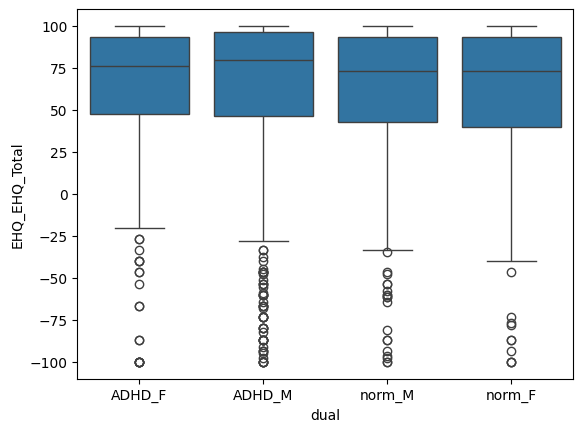

In [32]:
sns.boxplot(quantDF, x="dual", y="EHQ_EHQ_Total");

In [33]:
# handedness - not correlated to ADHD-gender
handed = quantDF.groupby("dual")["EHQ_EHQ_Total"].apply(list).to_dict()

# Kruskal-Wallis test
h_statistic, p_value = stats.kruskal(handed["ADHD_F"], handed["ADHD_M"], handed["norm_F"], handed["norm_M"])

print("Kruskal-Wallis H statistic:", h_statistic)
print("P-value:", p_value)

Kruskal-Wallis H statistic: 1.9942716451402138
P-value: 0.5735964969225513


In [34]:
# handedness - not correlated to ADHD
handed = quantDF.groupby("ADHD_Outcome")["EHQ_EHQ_Total"].apply(list).to_dict()

# Kruskal-Wallis test
h_statistic, p_value = stats.kruskal(handed[0], handed[1])

print("Kruskal-Wallis H statistic:", h_statistic)
print("P-value:", p_value)

Kruskal-Wallis H statistic: 1.2833748147828672
P-value: 0.25727248737361785


In [35]:
# handedness - not correlated to gender
handed = quantDF.groupby("Sex_F")["EHQ_EHQ_Total"].apply(list).to_dict()

# Kruskal-Wallis test
h_statistic, p_value = stats.kruskal(handed[0], handed[1])

print("Kruskal-Wallis H statistic:", h_statistic)
print("P-value:", p_value)

Kruskal-Wallis H statistic: 0.9443054280575405
P-value: 0.331173049878443


#### vision

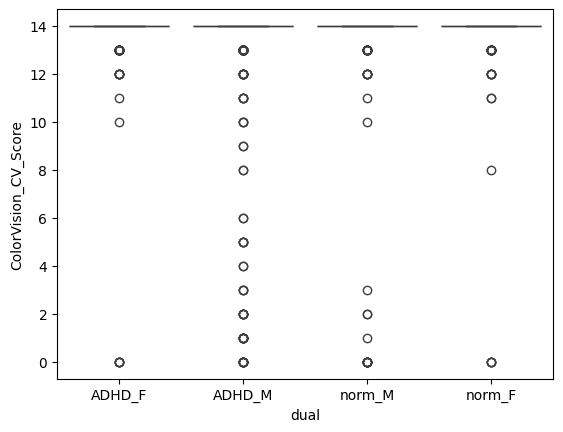

In [36]:
sns.boxplot(quantDF, x="dual", y="ColorVision_CV_Score");

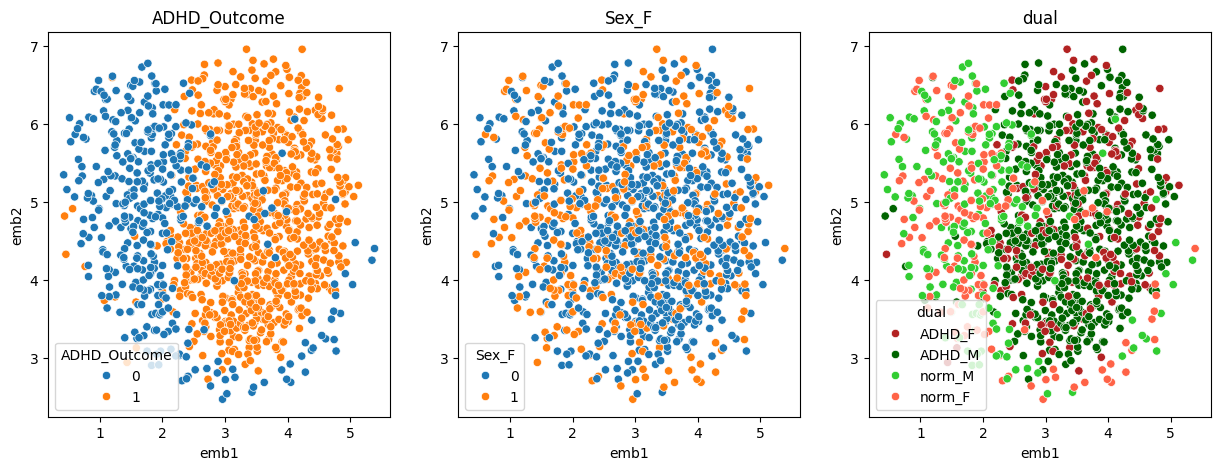

In [10]:
mri_embed = pd.DataFrame(
    umap.UMAP(random_state=42).fit_transform(mriDF[mri_cols]), columns=["emb1", "emb2"]
)
mri_embed[label_list] = mriDF[label_list]

fig, axs = plt.subplots(ncols=len(label_list), figsize=(15, 5))
for i, label in enumerate(label_list):
    if label=="dual":
        g = sns.scatterplot(data=mri_embed, x="emb1", y="emb2", hue=label, ax=axs[i], palette=palette_dual)
    else:
        g = sns.scatterplot(data=mri_embed, x="emb1", y="emb2", hue=label, ax=axs[i])
    g.set_title(label)

/Users/erinchinn/mamba/envs/my_env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erinchinn/mamba/envs/my_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


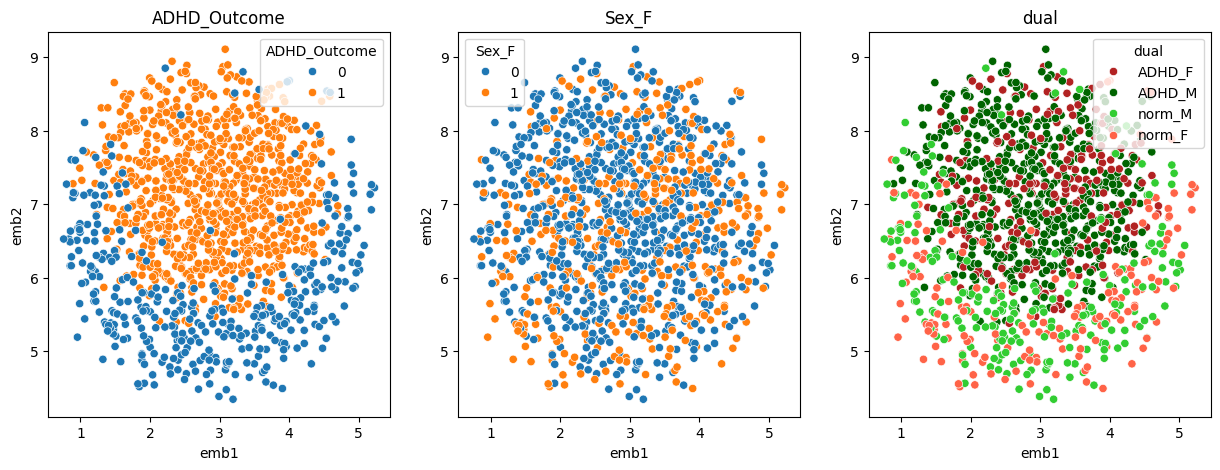

In [11]:
# top columns that have overall difference between ADHD diagnosis
mean_adhd = mriDF.groupby(["ADHD_Outcome"])[mri_cols].mean().reset_index()
cols_diff_adhd = (
    abs(mean_adhd.loc[0, mri_cols] - mean_adhd.loc[1, mri_cols])
    .sort_values(ascending=False)[:2600]
    .index.to_list()
)

embed_adhd = pd.DataFrame(
    umap.UMAP(random_state=42).fit_transform(mriDF[cols_diff_adhd]),
    columns=["emb1", "emb2"],
)

embed_adhd[label_list] = mriDF[label_list]

fig, axs = plt.subplots(ncols=len(label_list), figsize=(15, 5))
for i, label in enumerate(label_list):
    if label=="dual":
        g = sns.scatterplot(data=embed_adhd, x="emb1", y="emb2", hue=label, ax=axs[i], palette=palette_dual)
    else:
        g = sns.scatterplot(data=embed_adhd, x="emb1", y="emb2", hue=label, ax=axs[i])
    g.set_title(label)

/Users/erinchinn/mamba/envs/my_env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erinchinn/mamba/envs/my_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


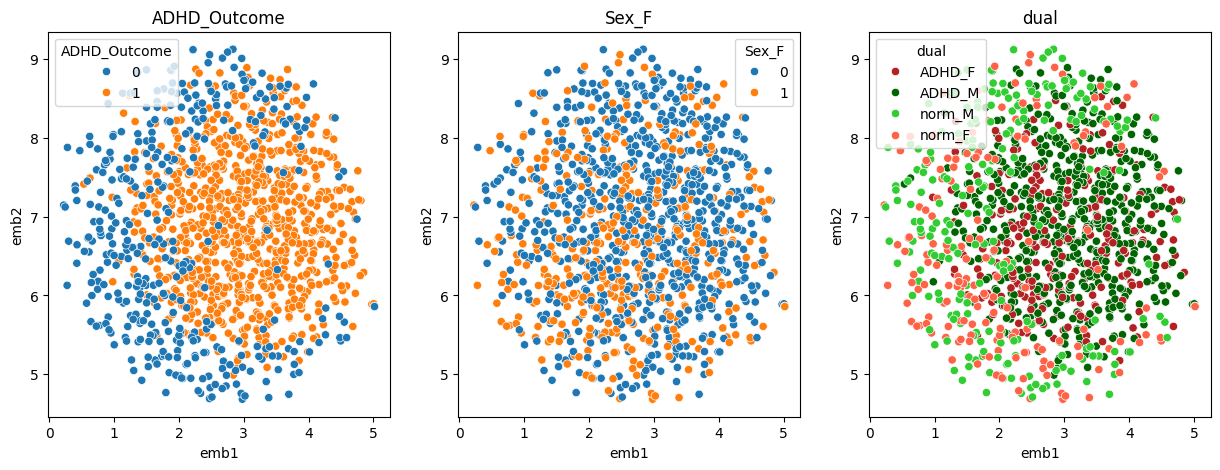

In [12]:
# top cols that have overall difference between gender
mean_gender = mriDF.groupby(["Sex_F"])[mri_cols].mean().reset_index()
cols_diff_gender = (
    abs(mean_gender.loc[0, mri_cols] - mean_gender.loc[1, mri_cols])
    .sort_values(ascending=False)[:3500]
    .index.to_list()
)

embed_gender = pd.DataFrame(
    umap.UMAP(random_state=42).fit_transform(mriDF[cols_diff_gender]),
    columns=["emb1", "emb2"],
)
embed_gender[label_list] = mriDF[label_list]

fig, axs = plt.subplots(ncols=len(label_list), figsize=(15, 5))
for i, label in enumerate(label_list):
    if label=="dual":
        g = sns.scatterplot(data=embed_gender, x="emb1", y="emb2", hue=label, ax=axs[i], palette=palette_dual)
    else:
        g = sns.scatterplot(data=embed_gender, x="emb1", y="emb2", hue=label, ax=axs[i])
    g.set_title(label)

In [13]:
top_corr_adhd = abs(mriDF[mri_cols].corrwith(mriDF["ADHD_Outcome"])).sort_values(ascending=False)[:40]
top_corr_gender = abs(mriDF[mri_cols].corrwith(mriDF["Sex_F"])).sort_values(ascending=False)[:40]

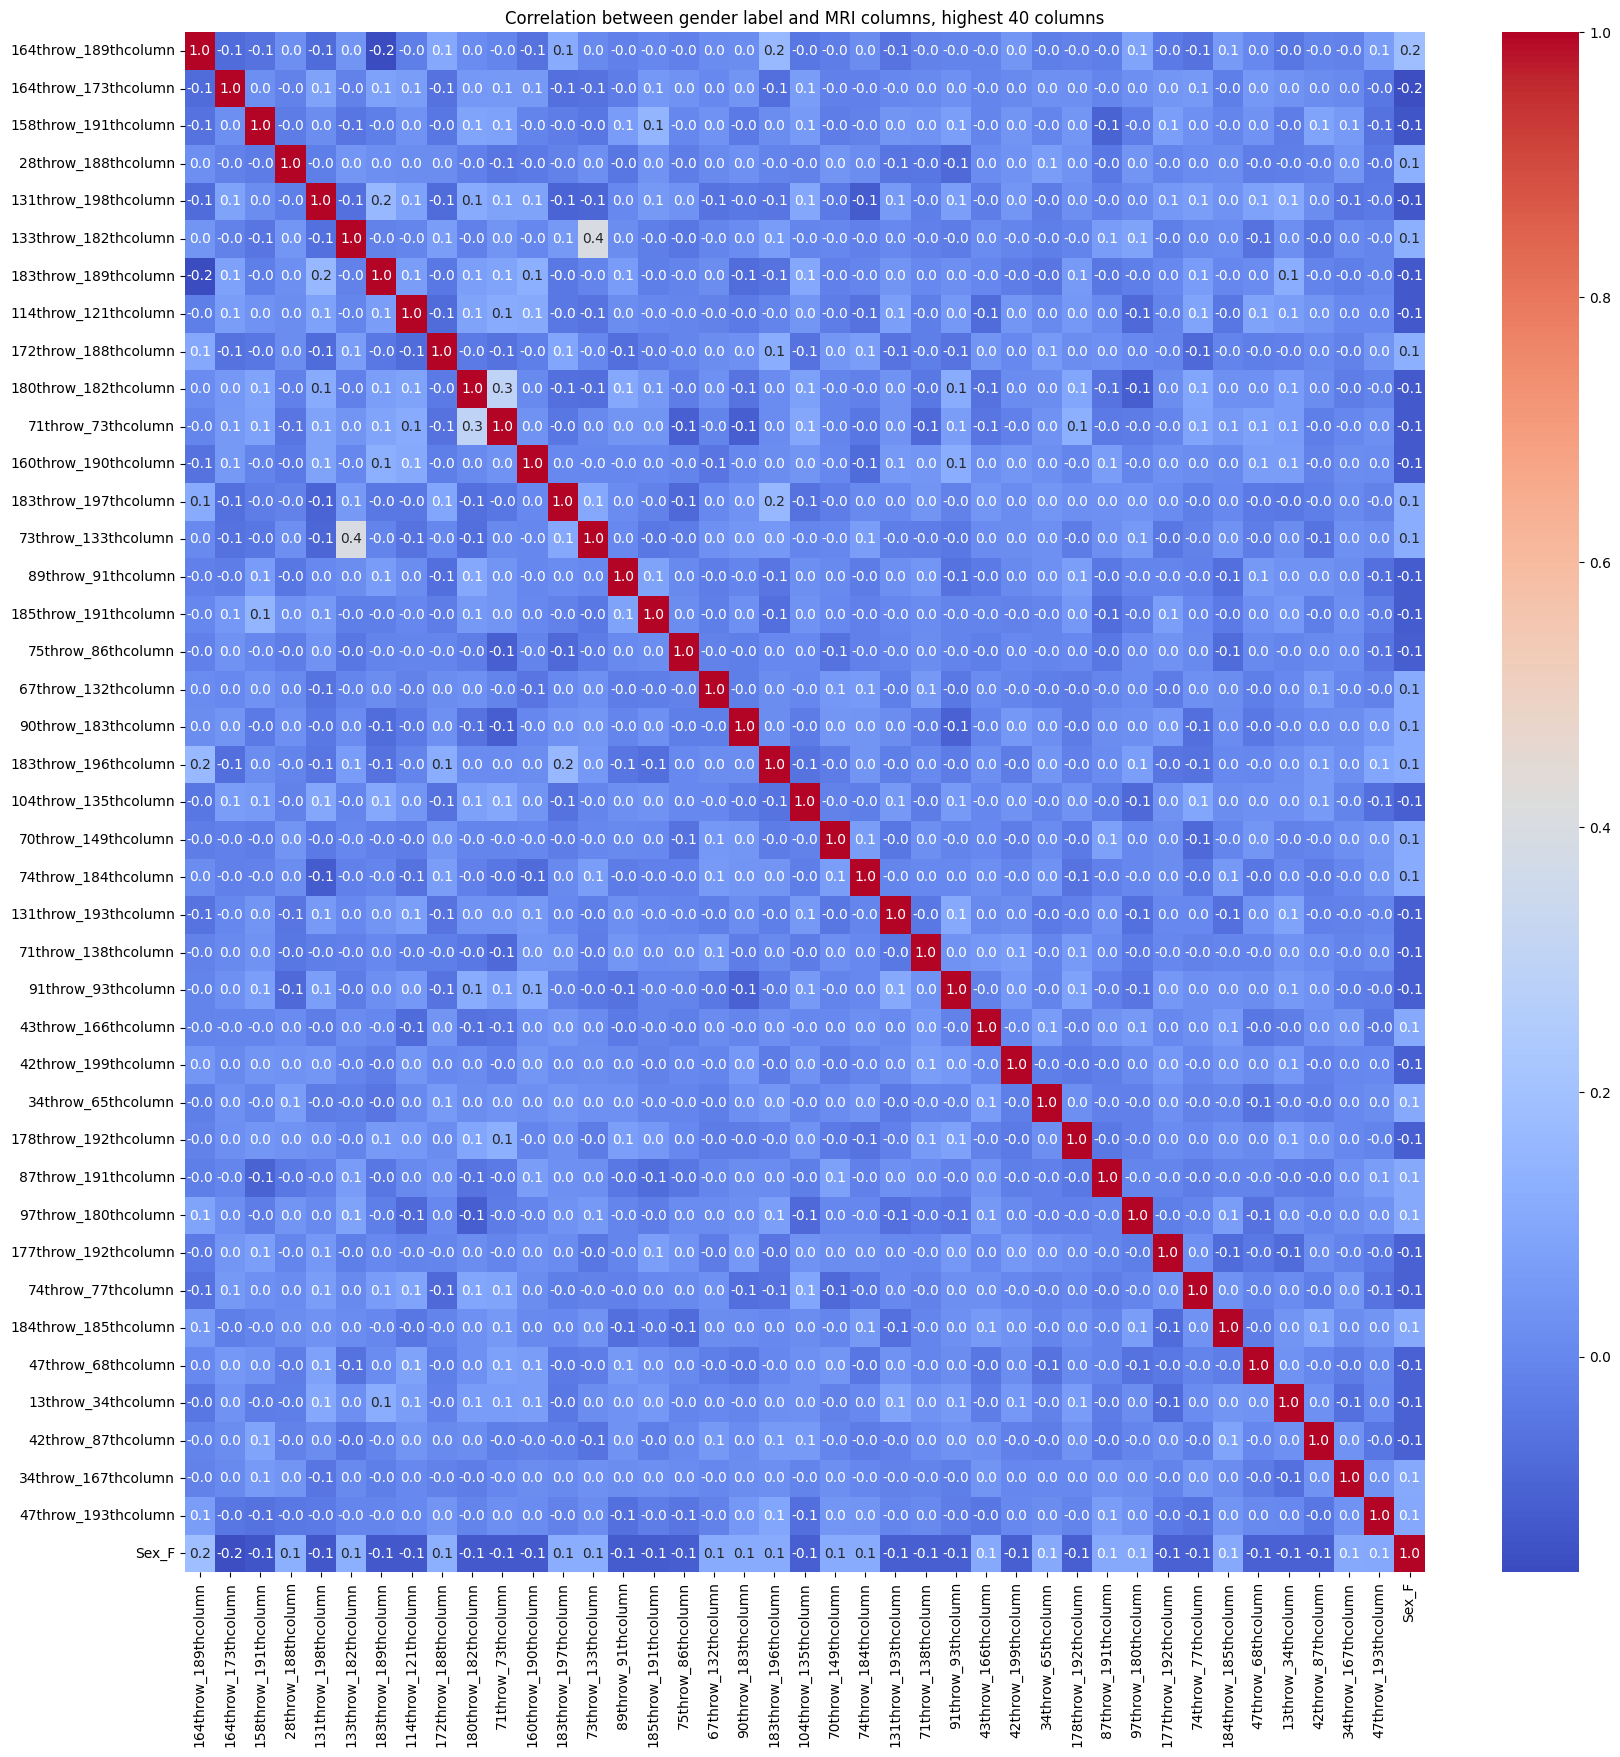

In [14]:
fig, ax = plt.subplots(figsize=(20,20))
g = sns.heatmap(
    mriDF[top_corr_gender.index.to_list() + ["Sex_F"]].corr(), 
    annot=True, 
    fmt=".1f", 
    cmap="coolwarm", 
    ax=ax)
g.set_title("Correlation between gender label and MRI columns, highest 40 columns")
plt.show()

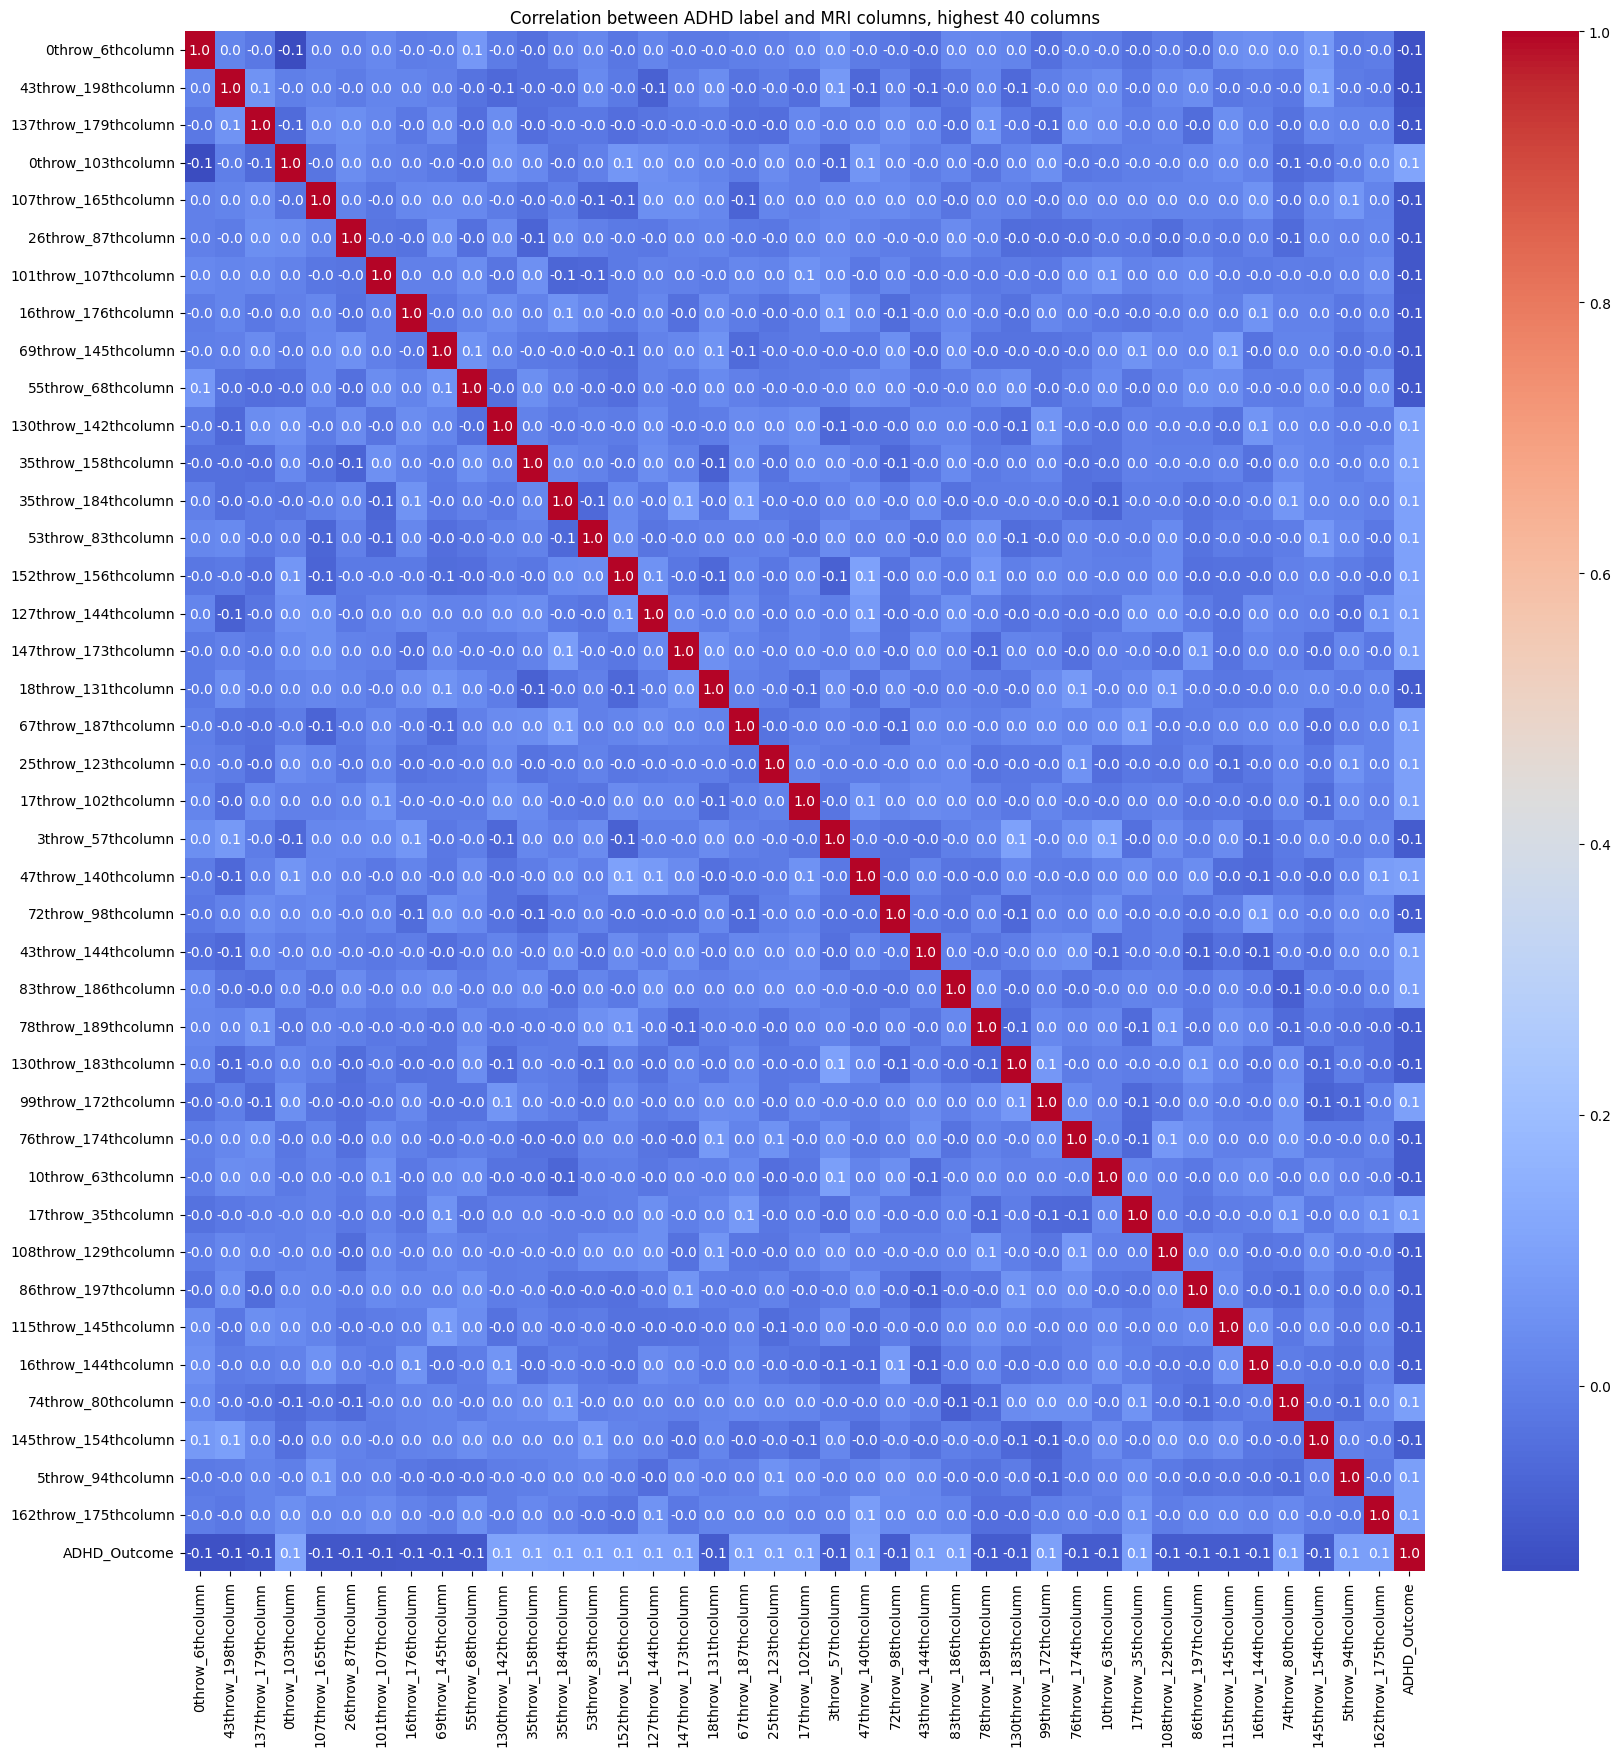

In [15]:
fig, ax = plt.subplots(figsize=(20,20))
g = sns.heatmap(
    mriDF[top_corr_adhd.index.to_list() + ["ADHD_Outcome"]].corr(), 
    annot=True, 
    fmt=".1f", 
    cmap="coolwarm", 
    ax=ax)
g.set_title("Correlation between ADHD label and MRI columns, highest 40 columns")
plt.show()

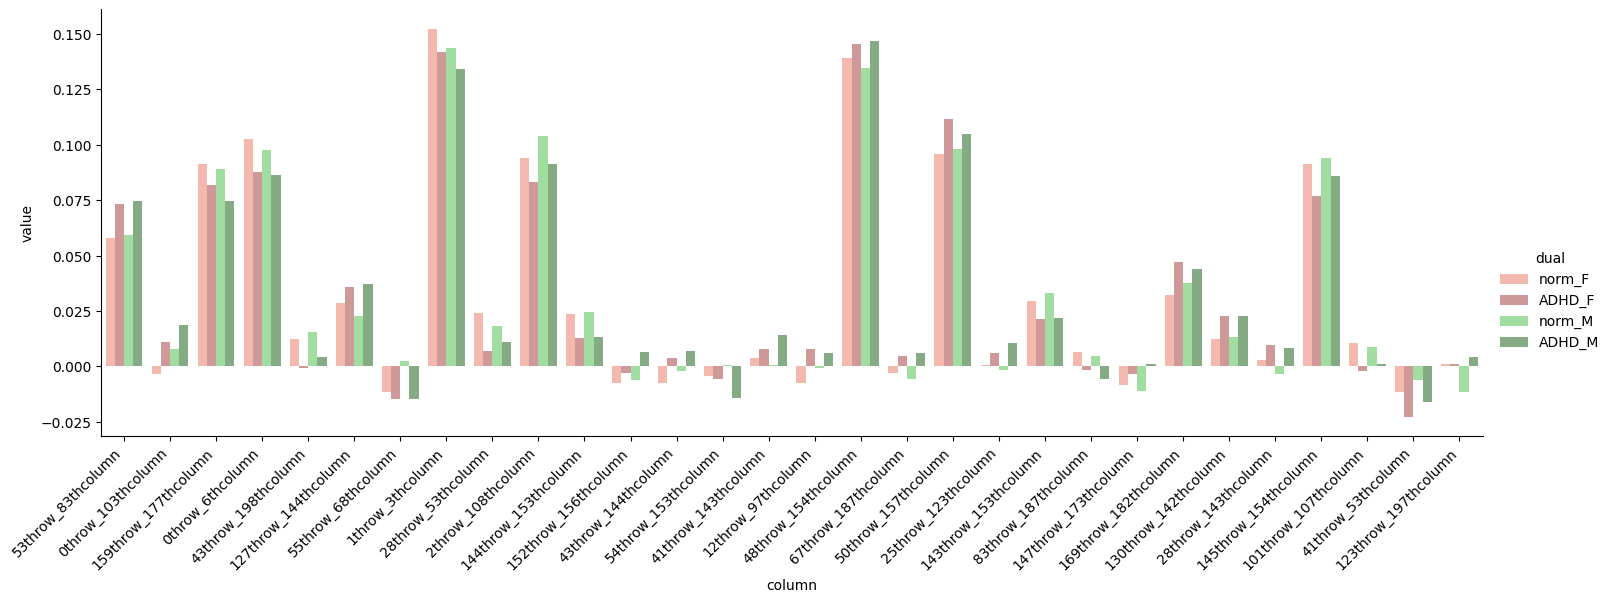

In [16]:
meltedmriDF = mriDF[label_list + cols_diff_adhd[:30]].melt(
    id_vars=label_list,
    var_name="column",
    value_name="value")

g = sns.catplot(
    data=meltedmriDF,
    x="column",
    y="value",
    hue="dual",
    kind="bar",
    alpha=0.5,
    height=5,
    aspect=3,
    # errorbar="sd", 
    errorbar=None,
    palette=palette_dual,
    hue_order=["norm_F", "ADHD_F", "norm_M", "ADHD_M"],
)

g.set_xticklabels(
    rotation=45, 
    horizontalalignment="right"
)

In [17]:
mriDF[mri_cols].describe()

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,...,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000
mean,0.060553,0.122315,0.060268,0.041287,0.069722,0.091007,0.066852,0.000252,0.014128,-0.002914,...,0.011075,-0.004938,-0.004378,0.001610,0.115171,0.049984,0.058144,0.093527,0.089403,0.128946
std,0.064178,0.054026,0.057495,0.043491,0.044222,0.049189,0.046864,0.049046,0.038205,0.042462,...,0.049632,0.046536,0.042900,0.047424,0.057128,0.051664,0.057674,0.054594,0.058036,0.058490
min,-0.183279,-0.059932,-0.145566,-0.127827,-0.072043,-0.079184,-0.105722,-0.164297,-0.137728,-0.148490,...,-0.161666,-0.176523,-0.178688,-0.138048,-0.070094,-0.153540,-0.131455,-0.085566,-0.204160,-0.083077
25%,0.018482,0.086102,0.026548,0.014457,0.042462,0.057614,0.036934,-0.031358,-0.010635,-0.030538,...,-0.021376,-0.033424,-0.033798,-0.030132,0.080291,0.015827,0.022316,0.059621,0.053224,0.090459
50%,0.058276,0.123220,0.061339,0.043246,0.067066,0.086494,0.067247,0.002549,0.016130,-0.002604,...,0.010254,-0.004683,-0.003724,0.000990,0.113640,0.052705,0.059151,0.093397,0.088612,0.127913
75%,0.100103,0.154518,0.099056,0.068408,0.096504,0.119404,0.095117,0.031053,0.038770,0.024507,...,0.044165,0.024913,0.024007,0.032268,0.150524,0.082526,0.095192,0.127144,0.127613,0.166523
max,0.321522,0.390895,0.278429,0.189825,0.317500,0.316811,0.270018,0.168196,0.145364,0.128301,...,0.194616,0.183152,0.180562,0.192015,0.375635,0.228748,0.322084,0.348153,0.267162,0.414304
